# Disease Prediction from Medical Data
### Predicting Breast Cancer Diagnosis using Classification Algorithms

**Objective:** Predict whether a tumor is malignant or benign using diagnostic medical measurements.

**Approach:** Logistic Regression, Random Forest, and SVM classifiers.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) - a real medical dataset of 569 patients, 30 features computed from digitized images of breast mass tissue (e.g. radius, texture, perimeter, smoothness, concavity).

**Evaluation Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC.

---

## 1. Imports

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
%matplotlib inline

RANDOM_STATE = 42

## 2. Load Dataset

This is the classic **Breast Cancer Wisconsin (Diagnostic)** dataset, saved to `../data/breast_cancer_data.csv`. Target column: `diagnosis` (1 = malignant, 0 = benign).

In [3]:
df = pd.read_csv('../data/breast_cancer_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
print('Missing values:', df.isna().sum().sum())
print('Malignant rate:', round(df['diagnosis'].mean() * 100, 2), '%')

Missing values: 0
Malignant rate: 37.26 %


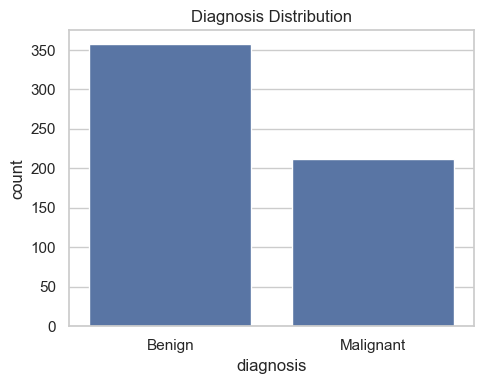

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='diagnosis')
plt.title('Diagnosis Distribution')
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.tight_layout(); plt.show()

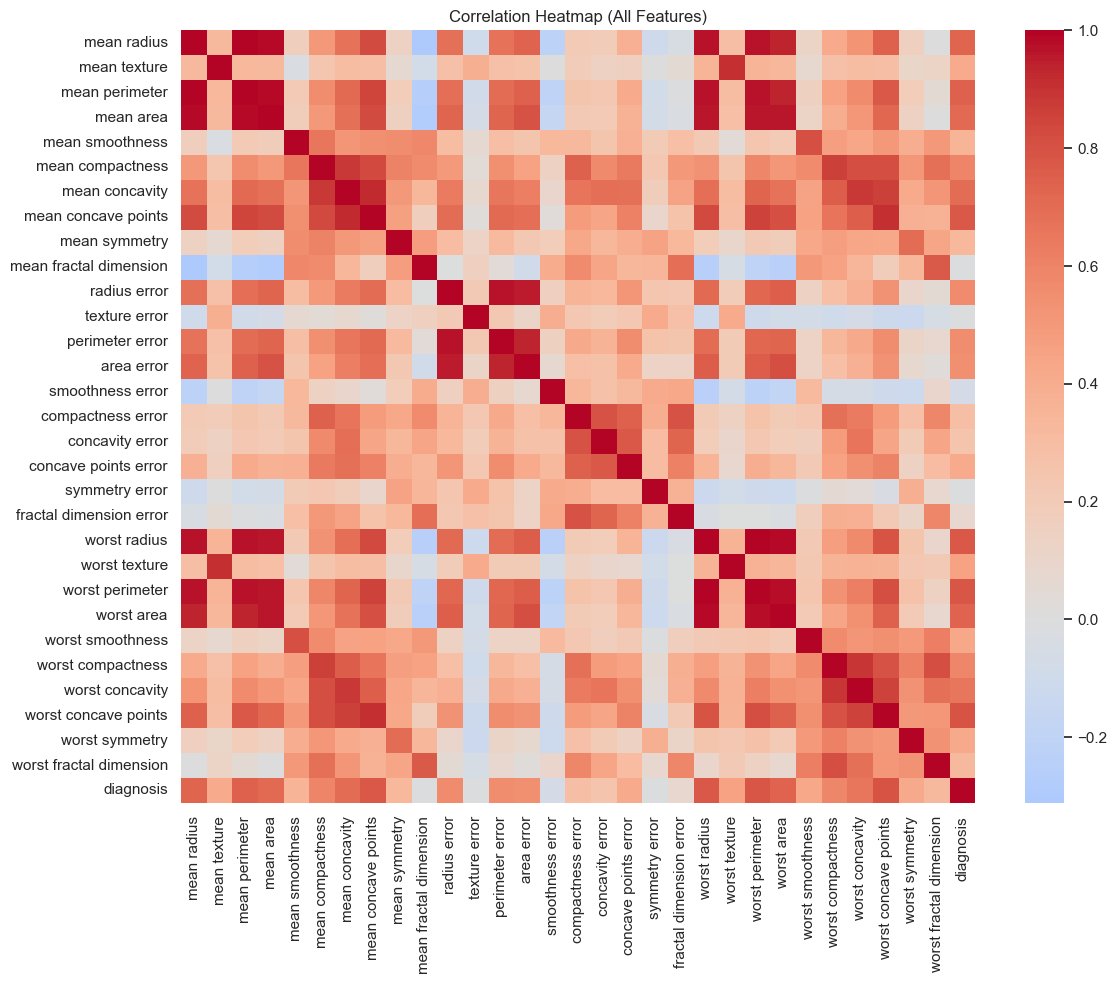

In [7]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (All Features)')
plt.tight_layout(); plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_15180\3124195502.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benign', 'Malignant'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_15180\3124195502.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benign', 'Malignant'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_15180\3124195502.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benign', 'Malignant'])


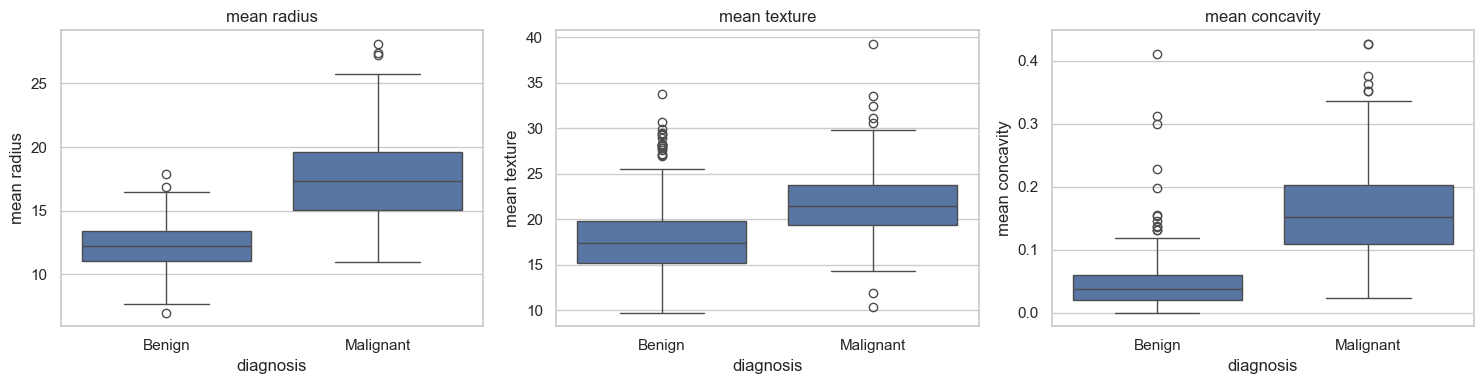

In [8]:
# Distribution of a few key diagnostic features by diagnosis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['mean radius', 'mean texture', 'mean concavity']):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=ax)
    ax.set_xticklabels(['Benign', 'Malignant'])
    ax.set_title(col)
plt.tight_layout(); plt.show()

No missing values in this dataset - it's already clean, so no imputation step is needed here (unlike Task 1's credit data).

## 4. Train / Test Split + Scaling

In [9]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Train:', X_train_s.shape, ' Test:', X_test_s.shape)

Train: (455, 30)  Test: (114, 30)


## 5. Model Training

Three classifiers, all with `class_weight='balanced'` since malignant cases are the minority class (~37%).

In [10]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    print(f'Trained: {name}')

Trained: Logistic Regression
Trained: Random Forest
Trained: SVM


## 6. Evaluation

In [11]:
results = []
roc_data = {}

for name, model in models.items():
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })
    roc_data[name] = roc_curve(y_test, y_proba) + (roc_auc_score(y_test, y_proba),)

    print(f'\n{"="*55}\n{name}\n{"="*55}')
    print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df


Logistic Regression
               precision    recall  f1-score   support

   Benign (0)       0.97      0.99      0.98        72
Malignant (1)       0.98      0.95      0.96        42

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114


Random Forest
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114


SVM
               precision    recall  f1-score   support

   Benign (0)       0.99      0.99      0.99        72
Malignant (1)       0.98      0.98      0.98        42

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg   

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.973684,1.00000,0.928571,0.962963,0.997024
1,SVM,0.982456,0.97619,0.976190,0.976190,0.995370
2,Logistic Regression,0.973684,0.97561,0.952381,0.963855,0.995370


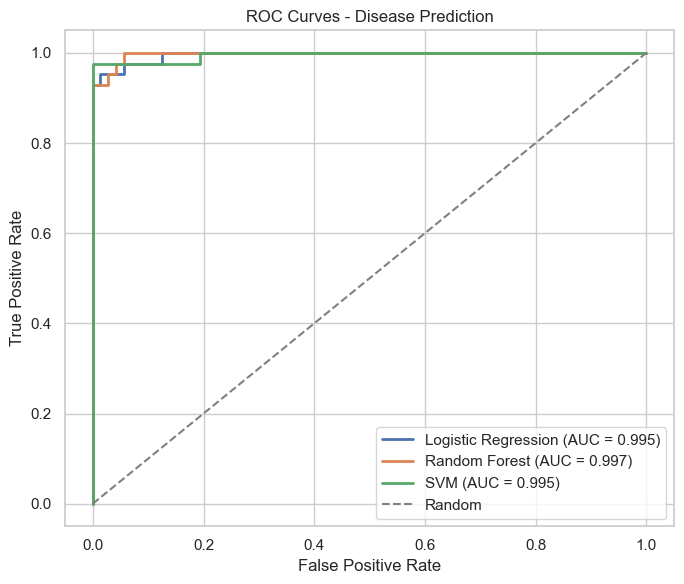

In [12]:
# ROC Curves
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, _, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Disease Prediction'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

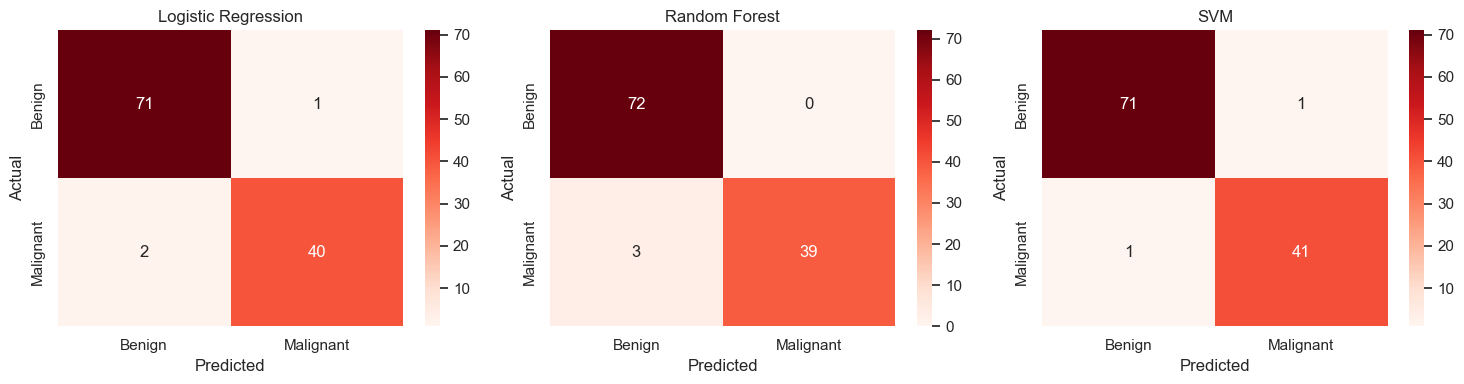

In [13]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

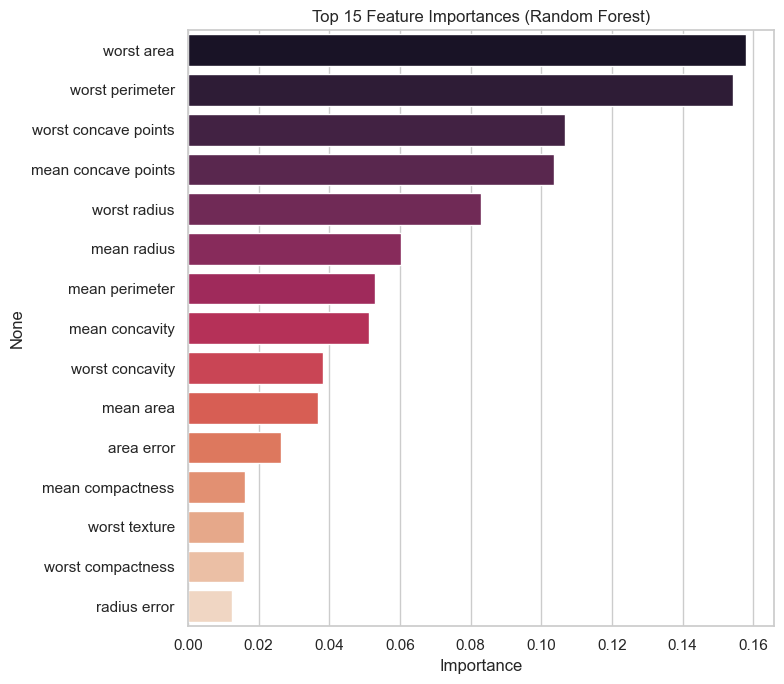

In [14]:
# Feature Importance (Random Forest)
importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 7))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='rocket', legend=False)
plt.title('Top 15 Feature Importances (Random Forest)'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()

## 7. Model Selection

Best model chosen by **ROC-AUC** - especially important in medical diagnosis, where missing a malignant case (false negative) is far more costly than a false alarm.

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f'Best model: {best_model_name} (ROC-AUC = {results_df.iloc[0]["ROC-AUC"]:.4f})')

Best model: Random Forest (ROC-AUC = 0.9970)


## 8. Save Predictions

In [16]:
predictions_df = X_test.copy()
predictions_df['actual_diagnosis'] = y_test.values
predictions_df['predicted_diagnosis'] = best_model.predict(X_test_s)
predictions_df['predicted_probability'] = best_model.predict_proba(X_test_s)[:, 1].round(4)

import os
os.makedirs('../results', exist_ok=True)
predictions_df.to_csv('../results/predictions.csv', index=False)
results_df.to_csv('../results/model_comparison_results.csv', index=False)

predictions_df[['actual_diagnosis', 'predicted_diagnosis', 'predicted_probability']].head(10)

,actual_diagnosis,predicted_diagnosis,predicted_probability
120,0,0,0.0110
250,1,1,0.9976
375,0,0,0.4200
99,1,1,0.6127
455,0,0,0.0925
318,0,0,0.1563
39,1,1,0.6393
371,0,0,0.1934
98,0,0,0.0007
502,0,0,0.0040


## 9. Save the Trained Model

In [17]:
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(
    {'model': best_model, 'scaler': scaler, 'feature_columns': list(X.columns), 'model_name': best_model_name},
    '../models/best_model.pkl',
)
print('Saved to ../models/best_model.pkl')

Saved to ../models/best_model.pkl


## 10. Predict a New Patient

A helper function to score a new patient's diagnostic measurements.

In [18]:
def predict_new_patient(measurements_dict, model=best_model, scaler=scaler, feature_columns=list(X.columns)):
    df_one = pd.DataFrame([measurements_dict])[feature_columns]
    df_one_scaled = pd.DataFrame(scaler.transform(df_one), columns=feature_columns)
    pred_class = model.predict(df_one_scaled)[0]
    pred_proba = model.predict_proba(df_one_scaled)[0, 1]
    return pred_class, round(pred_proba, 4)

# Example: using an existing test-set patient's measurements
sample_patient = X_test.iloc[0].to_dict()
pred_class, pred_proba = predict_new_patient(sample_patient)
print('Predicted diagnosis:', 'MALIGNANT' if pred_class == 1 else 'BENIGN')
print(f'Malignancy probability: {pred_proba:.2%}')
print('Actual diagnosis was:', 'MALIGNANT' if y_test.iloc[0] == 1 else 'BENIGN')

Predicted diagnosis: BENIGN
Malignancy probability: 1.10%
Actual diagnosis was: BENIGN


## 11. Conclusion

- All three models achieved strong performance (ROC-AUC > 0.99), which is expected - this dataset is a well-known, highly separable benchmark in medical ML.
- The best model was selected automatically by ROC-AUC.
- Top predictive features (via Random Forest importance) align with known clinical indicators of malignancy, such as cell radius, concavity, and area.
- The trained model and scaler are saved to `../models/best_model.pkl` for reuse.